In [1]:
# 导入所需库
import numpy as np
import pandas as pd
import xgboost as xgb
import random
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码.
random.seed(55)

In [2]:
# 加载数据
df = pd.read_csv('data.csv', encoding='utf-8-sig')
df

,支架杆厚度(mm),环间距(mm),杨氏模量(GPa),血管管径(mm),血流量(mL/s),最大von Mises应力(MPa),最大位移(mm),径向强度(N),回缩率(%),压降(Pa)
0,0.17,1.45,58,3.7,112,327,0.21,1.23,14.0,128
1,0.14,1.27,52,3.2,87,287,0.18,1.20,14.0,112
2,0.17,1.45,63,3.7,112,287,0.21,1.23,14.0,128
3,0.17,1.28,58,3.7,112,327,0.21,1.30,14.0,128
4,0.14,1.72,52,3.7,89,287,0.18,1.20,14.0,112
...,...,...,...,...,...,...,...,...,...,...
311,0.15,1.47,52,3.7,112,287,0.18,1.20,14.0,98
312,0.17,1.35,58,3.7,92,287,0.18,1.20,14.0,112
313,0.15,1.47,58,3.7,112,287,0.18,1.20,14.0,123
314,0.14,1.35,52,3.7,112,287,0.18,1.20,14.0,98


In [3]:
# 数据准备
# 特征：前5列；多标签：后四列
X = df.iloc[:, :5]             # 前5列为特征
y = df.iloc[:, -4:]            # 后4列为多标签

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"训练集: {X_train.shape}, 测试集: {X_test.shape}")

训练集: (252, 5), 测试集: (64, 5)


In [4]:
from sklearn.metrics import mean_squared_error as mse
# 超参数范围
param_bounds = {
    'n_estimators': (50, 500),
    'max_depth': (3, 10),
    'learning_rate': (0.01, 0.3),
    'subsample': (0.5, 1.0),
    'colsample_bytree': (0.5, 1.0),
}

# 种群初始化
def init_population(pop_size):
    pop = []
    for _ in range(pop_size):
        ind = {
            'n_estimators': random.randint(*param_bounds['n_estimators']),
            'max_depth': random.randint(*param_bounds['max_depth']),
            'learning_rate': random.uniform(*param_bounds['learning_rate']),
            'subsample': random.uniform(*param_bounds['subsample']),
            'colsample_bytree': random.uniform(*param_bounds['colsample_bytree']),
        }
        pop.append(ind)
    return pop

# 适应度：3 折 CV RMSE
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))
    
def fitness(ind):
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    total_rmse = []

    for tr_idx, val_idx in kf.split(X_train):
        fold_rmse = []

        for col in y_train.columns:
            model = xgb.XGBRegressor(objective='reg:squarederror', **ind)
            model.fit(X_train.iloc[tr_idx], y_train[col].iloc[tr_idx])
            pred = model.predict(X_train.iloc[val_idx])
            rmse = root_mean_squared_error(y_train[col].iloc[val_idx], pred)
            fold_rmse.append(rmse)
        
        avg_rmse = np.mean(fold_rmse)
        total_rmse.append(avg_rmse)

    return np.mean(total_rmse)


# 选择、交叉、变异
def tournament_selection(pop, fits, k=3):
    selected = []
    for _ in pop:
        aspirants = random.sample(list(zip(pop, fits)), k)
        selected.append(min(aspirants, key=lambda x: x[1])[0])
    return selected

def crossover(p1, p2):
    child = {}
    for key in param_bounds:
        child[key] = p1[key] if random.random() < 0.5 else p2[key]
    return child

def mutate(ind, mrate=0.1):
    for key, bound in param_bounds.items():
        if random.random() < mrate:
            if isinstance(bound[0], int):
                ind[key] = random.randint(*bound)
            else:
                ind[key] = random.uniform(*bound)
    return ind

In [5]:
# Cell 5: 运行遗传算法
pop_size = 10
gens = 30
mrate = 0.2

population = init_population(pop_size)

mean_target_value = float(np.mean(y_train.values))

best_ind, best_rmse = None, float('inf') 
history = []

for gen in range(gens):
    fits = [fitness(ind) for ind in population]
    # 更新最优
    idx = np.argmin(fits)
    if fits[idx] < best_rmse:
        best_rmse = fits[idx]
        best_ind = population[idx].copy()
    history.append(best_rmse)
    
    cv_rmse = best_rmse / mean_target_value
    print(f"第 {gen+1} 代, 最佳 CV RMSE = {cv_rmse:.4f}")
    # 进化
    sel = tournament_selection(population, fits)
    next_pop = []
    for i in range(0, pop_size, 2):
        c1 = mutate(crossover(sel[i], sel[(i+1)%pop_size]), mrate)
        c2 = mutate(crossover(sel[(i+1)%pop_size], sel[i]), mrate)
        next_pop += [c1, c2]
    population = next_pop

第 1 代, 最佳 CV RMSE = 0.1026
第 2 代, 最佳 CV RMSE = 0.1010
第 3 代, 最佳 CV RMSE = 0.0967
第 4 代, 最佳 CV RMSE = 0.0916
第 5 代, 最佳 CV RMSE = 0.0916
第 6 代, 最佳 CV RMSE = 0.0898
第 7 代, 最佳 CV RMSE = 0.0898
第 8 代, 最佳 CV RMSE = 0.0898
第 9 代, 最佳 CV RMSE = 0.0898
第 10 代, 最佳 CV RMSE = 0.0898
第 11 代, 最佳 CV RMSE = 0.0898
第 12 代, 最佳 CV RMSE = 0.0898
第 13 代, 最佳 CV RMSE = 0.0897
第 14 代, 最佳 CV RMSE = 0.0897
第 15 代, 最佳 CV RMSE = 0.0897
第 16 代, 最佳 CV RMSE = 0.0897
第 17 代, 最佳 CV RMSE = 0.0897
第 18 代, 最佳 CV RMSE = 0.0897
第 19 代, 最佳 CV RMSE = 0.0897
第 20 代, 最佳 CV RMSE = 0.0897
第 21 代, 最佳 CV RMSE = 0.0897
第 22 代, 最佳 CV RMSE = 0.0897
第 23 代, 最佳 CV RMSE = 0.0897
第 24 代, 最佳 CV RMSE = 0.0897
第 25 代, 最佳 CV RMSE = 0.0897
第 26 代, 最佳 CV RMSE = 0.0897
第 27 代, 最佳 CV RMSE = 0.0897
第 28 代, 最佳 CV RMSE = 0.0895
第 29 代, 最佳 CV RMSE = 0.0895
第 30 代, 最佳 CV RMSE = 0.0895


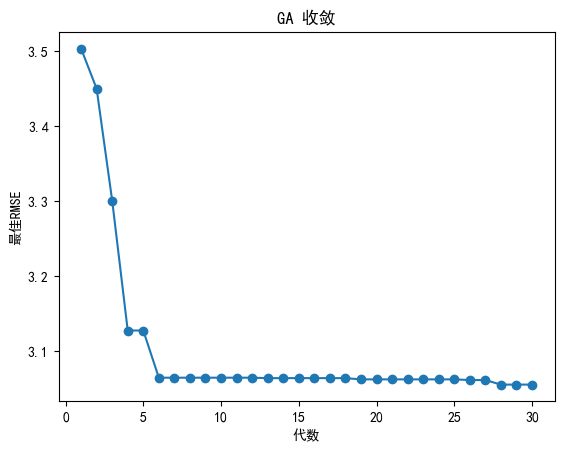

最优超参数： {'n_estimators': 60, 'max_depth': 3, 'learning_rate': 0.025221023632643943, 'subsample': 0.549880886575423, 'colsample_bytree': 0.621368202950564}


In [10]:
# 收敛曲线
plt.plot(range(1, gens+1), history, marker='o')
plt.xlabel('代数')
plt.ylabel('最佳RMSE')
plt.title('GA 收敛')
plt.show()

print("最优超参数：", best_ind)

In [11]:
# Cell 6: 最终模型评估
final_model = xgb.XGBRegressor(objective='reg:squarederror', **best_ind)
final_model.fit(X_train, y_train)
pred_test = final_model.predict(X_test)
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"测试集 RMSE: {rmse_test:.4f}")


测试集 RMSE: 13.5773
